# Fig. 4h spatial benchmark metrics

This notebook redraws Fig. 4h from the copied `clustering_results_with_bar.csv` only.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

cwd = Path.cwd()
if (cwd / "figures_res" / "fig4").exists():
    FIG4_DIR = cwd / "figures_res" / "fig4"
elif cwd.name == "fig4" and (cwd / "data").exists():
    FIG4_DIR = cwd
else:
    raise FileNotFoundError("Run from repo root or figures_res/fig4.")

DATA_DIR = FIG4_DIR / "data" / "spatial"
OUTPUT_DIR = FIG4_DIR / "output" / "h"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="white", context="notebook")
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

METRICS = [
    "Silhouette Score",
    "Calinski-Harabasz Score",
    "Davies-Bouldin Score",
    "Modularity Score",
]


In [2]:
def draw_fig4h(csv_path=DATA_DIR / "clustering_results_with_bar.csv", save_prefix="fig4h_spatial_metrics"):
    df = pd.read_csv(csv_path)
    priority_list = ["LassoARE"]
    df = df[~df["Method"].isin([""])].copy()
    df["Mean Number of Clusters"] = df.groupby(["Method", "Resolution"])["Number of Clusters"].transform("mean")

    unique_methods = df["Method"].drop_duplicates().tolist()
    hue_order = [m for m in priority_list if m in unique_methods] + [m for m in unique_methods if m not in priority_list]

    fig, axes = plt.subplots(4, 1, figsize=(4, 17))
    axes = axes.flatten()
    handles = labels = None
    for i, metric in enumerate(METRICS):
        ax = axes[i]
        sns.lineplot(
            data=df,
            x="Mean Number of Clusters",
            y=metric,
            hue="Method",
            hue_order=hue_order,
            marker="o",
            errorbar=("ci", 95),
            ax=ax,
            legend=(i == 0),
        )
        ax.set_title(metric.replace("Davies-Bouldin Score", "Davies-Bouldin Score*\n*low is better"))
        ax.set_xlabel("Mean Number of Clusters")
        ax.grid(False)
        ax.spines[["top", "right"]].set_visible(False)
        if metric == "Calinski-Harabasz Score":
            ax.set_yscale("symlog")
            ax.set_ylim(bottom=100)
        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            if ax.legend_ is not None:
                ax.legend_.remove()

    fig.tight_layout()
    if handles:
        fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.72, 0.03), title="Method")
    fig.savefig(OUTPUT_DIR / f"{save_prefix}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{save_prefix}.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig


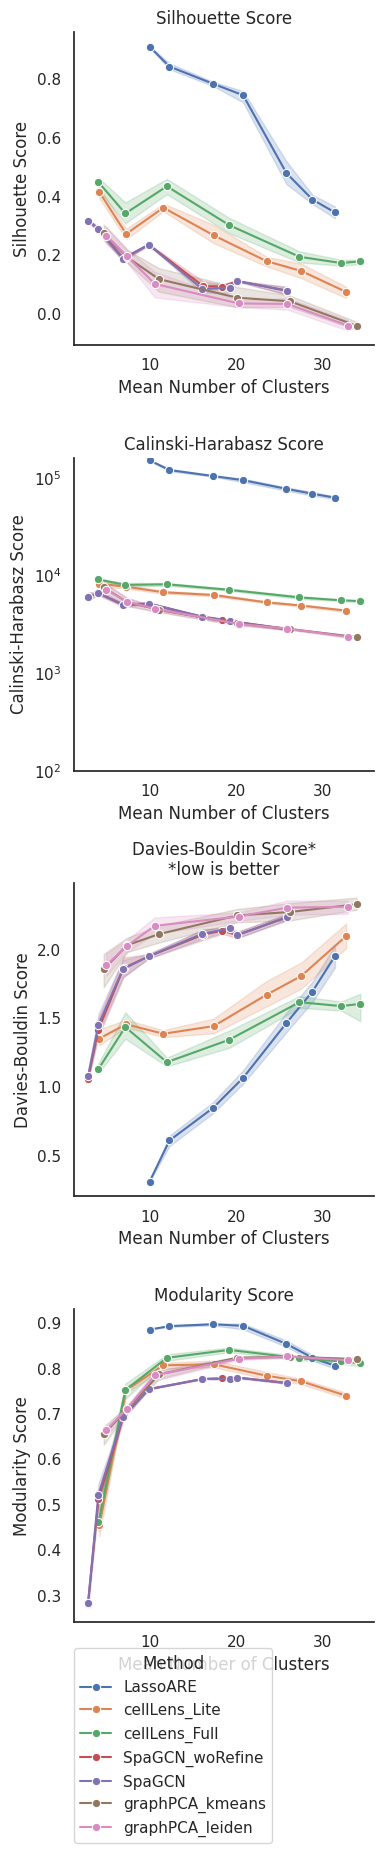

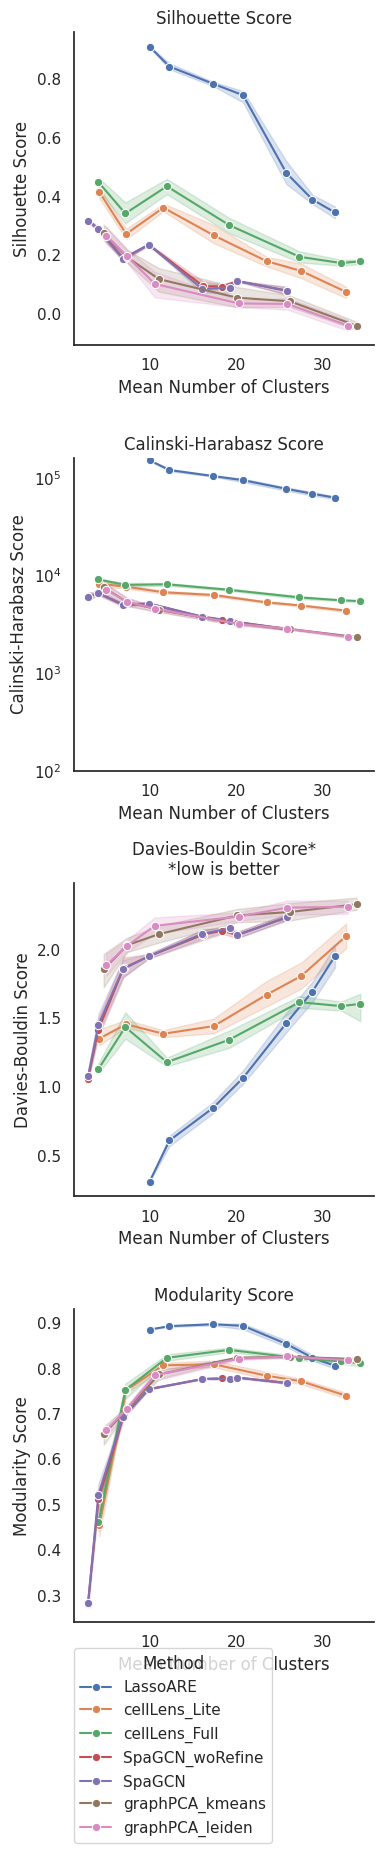

In [3]:
draw_fig4h()


## Display saved PNG outputs

Run this cell after the plotting cells above to render the saved PNG files directly inside the notebook for review.

In [ ]:
from pathlib import Path
from IPython.display import Image, Markdown, display


def display_saved_pngs(output_dir, width=1000):
    output_dir = Path(output_dir)
    pngs = sorted(output_dir.glob("*.png"))
    if not pngs:
        print(f"No PNG files found in {output_dir}. Run the plotting cells above first.")
        return
    for png in pngs:
        display(Markdown(f"### {png.name}"))
        display(Image(filename=str(png), width=width))


In [ ]:
display_saved_pngs(OUTPUT_DIR, width=900)
